# Analysis: Random Subspace Ensemble on Hyperspectral Data

This analysis demonstrates the practical application of the Random Subspace Ensemble (RSE) method to improve classification robustness in high-dimensional datasets. We apply this technique to the domain of Remote Sensing, specifically distinguishing between different land cover types using hyperspectral imaging.

---

## 1. The Dataset: Pavia University HSI

The data used is the Pavia University Hyperspectral Image, collected by the ROSIS sensor during a flight over Pavia, northern Italy.

**High Dimensionality:**  
We utilize 103 spectral bands for classification.

**The Task:**  
We focus on a specific binary classification problem: distinguishing between Class 4 (Trees) and Class 6 (Bare Soil).

---

## 2. The Method: Random Subspace Ensemble (RSE)

To address the high dimensionality, we employ the Random Subspace Method. Instead of training a single model on all 103 features, we construct an ensemble of 50 Perceptrons.

- **Feature Isolation:**  
  Each Perceptron in the ensemble is trained on a random subset of only 30 features ($D_{sub} \approx 30\%$).

- **Decorrelation:**  
  By forcing models to look at different parts of the spectrum, we prevent any single noisy or dominant band from controlling the decision boundary.

- **Aggregation:**  
  The final prediction is determined by a Majority Vote of the 50 "spectral experts."

---

## 3. Analysis Workflow

The code below implements the following pipeline:

- **Data Loading & Filtering:**  
  We load the raw .mat data cubes, reshape them into a 2D matrix (Samples $\times$ Features), and filter the dataset to retain only samples belonging to Trees (Class 4) and Bare Soil (Class 6).

- **Preprocessing:**  
  We apply Z-score standardization to normalize the 103 spectral bands, ensuring the Perceptron's gradient descent converges efficiently.

- **Model Training:**  
  - **Baseline:** A Single Perceptron trained on the full 103-feature set.  
  - **Ensemble:** An RSE of 50 Perceptrons, each restricted to a random 30-feature subspace.

- **Evaluation:**  
  We compare the performance of both approaches using Accuracy and Confusion Matrices to visualize the reduction in misclassification.

Loading and Filtering Pavia University HSI data for Class 4 and 6...
Data Filtered. Final Shape: 8093 samples, 103 features.

--- RSE with Perceptrons (Subset Size: 30, 50 models) ---
Training 50 models...

--- Single Perceptron (Comparison) ---

Single Perceptron Accuracy: 0.9786
RSE Perceptron Ensemble Accuracy: 0.9918


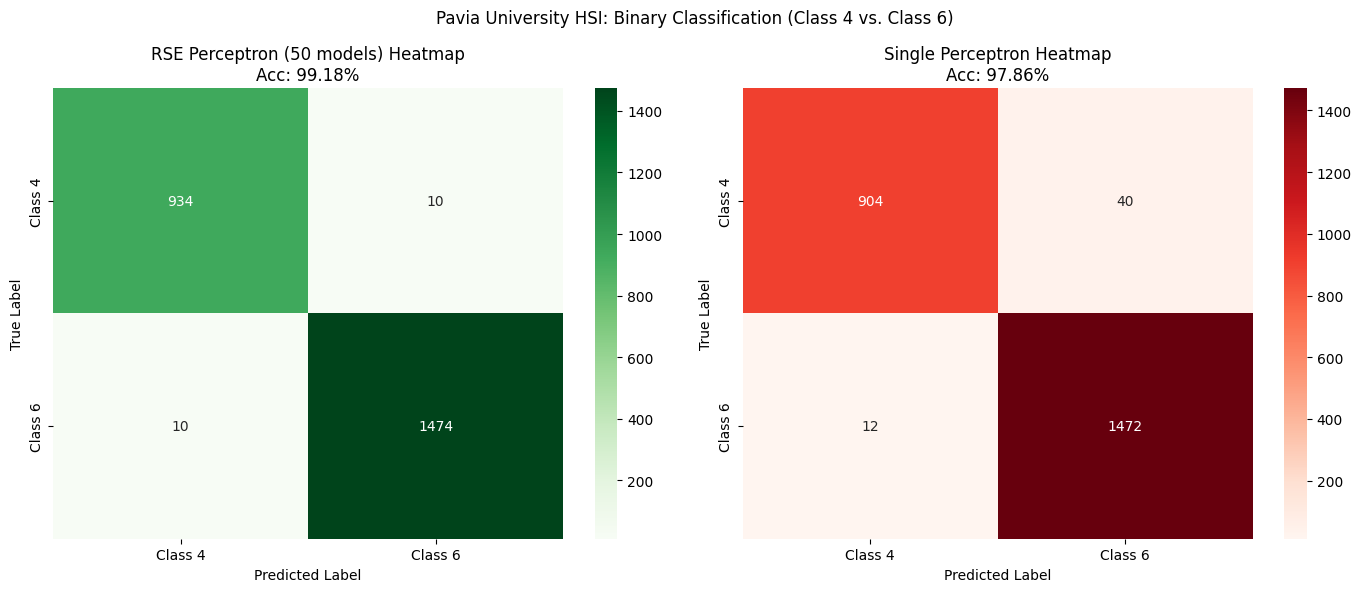

In [50]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# --- Custom Imports ---
# Import all required custom tools from the machine learning library
from ml import train_test_split_arrays, RandomSubspaceEnsemble, Perceptron, standardize_vectors


# ==========================================
# 1. Load, Reshape, and Filter Data
# ==========================================
print("Loading and Filtering Pavia University HSI data for Class 4 and 6...")

data_mat = scipy.io.loadmat('PaviaU.mat')
gt_mat = scipy.io.loadmat('PaviaU_gt.mat')

X_data = data_mat['paviaU']
y_labels_flattened = gt_mat['paviaU_gt'].flatten()

X_data_reshaped = X_data.reshape(-1, X_data.shape[2])
Y_zero_indexed = y_labels_flattened - 1 

# --- Binary Filtering and Relabeling ---
# Identify the two target classes (indices 3 and 5, corresponding to original classes 4 and 6)
TARGET_CLASSES_INDICES = [3, 5] 
mask = np.isin(Y_zero_indexed, TARGET_CLASSES_INDICES)

X_filtered = X_data_reshaped[mask]
Y_filtered = Y_zero_indexed[mask]

# Relabel Y_filtered to be a simple binary 0 and 1
# The first class (index 3) is assigned 0, the second class (index 5) is assigned 1
Y_binary = np.where(Y_filtered == 3, 0, 1)

N_SAMPLES, N_FEATURES = X_filtered.shape
print(f"Data Filtered. Final Shape: {N_SAMPLES} samples, {N_FEATURES} features.")

# ==========================================
# 2. Splitting and Standardizing Data
# ==========================================
# Use the custom split function
X_train, y_train, X_test, y_test = train_test_split_arrays(
    data=X_filtered, 
    labels=Y_binary, 
    train_ratio=0.7, 
    seed=42
)

# Standardize the data using training set statistics, ensuring robustness against zero standard deviation
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
std[std == 0] = 1e-8 

X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std


# ==========================================
# 3. RSE with Perceptrons
# ==========================================
n_subset = 30
n_repeats = 50

print(f"\n--- RSE with Perceptrons (Subset Size: {n_subset}, 50 models) ---")

# Initialize the base Perceptron with the expected subspace dimensionality
base_perceptron = Perceptron(n_features=n_subset) 

ensemble_perceptron = RandomSubspaceEnsemble(
    n_features_in_subset=n_subset, 
    task_type="classification"
)

ensemble_perceptron.add_model(
    model_init=base_perceptron,
    train_signature="train(X_TRAIN, Y_TRAIN, epochs=20, lr=0.01, verbose=False)",
    predict_signature="predict(X_TEST)",
    n_repeats=n_repeats
)

print(f"Training {n_repeats} models...")
ensemble_perceptron.fit(X_train_std, y_train)
y_pred_rse = ensemble_perceptron.predict(X_test_std)

# ==========================================
# 4. Single Base Model Comparison
# ==========================================
print("\n--- Single Perceptron (Comparison) ---")
# Initialize the single Perceptron with the full feature dimensionality
single_perceptron = Perceptron(X_train_std.shape[1]) 

single_perceptron.train(X_train_std, y_train, epochs=20, lr=0.01) 
y_pred_single = single_perceptron.predict(X_test_std)

# ==========================================
# 5. Results and Heatmaps
# ==========================================
acc_rse = accuracy_score(y_test, y_pred_rse)
acc_single = accuracy_score(y_test, y_pred_single)

print(f"\nSingle Perceptron Accuracy: {acc_single:.4f}")
print(f"RSE Perceptron Ensemble Accuracy: {acc_rse:.4f}")

# Plotting the Comparison Heatmaps
cm_rse = confusion_matrix(y_test, y_pred_rse)
cm_single = confusion_matrix(y_test, y_pred_single)

# Update class names for the plot to reflect the filtered classes (4 and 6)
class_names = ['Class 4', 'Class 6']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm_rse, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f'RSE Perceptron (50 models) Heatmap\nAcc: {acc_rse:.2%}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.subplot(1, 2, 2)
sns.heatmap(cm_single, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Single Perceptron Heatmap\nAcc: {acc_single:.2%}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.suptitle('Pavia University HSI: Binary Classification (Class 4 vs. Class 6)')
plt.tight_layout()
plt.show()

# Analysis: RSE vs. Single Perceptron Performance

The comparison between the Random Subspace Ensemble (RSE) and the Single Perceptron on the hyperspectral binary classification problem, which distinguishes between Trees (Class 4) and Bare Soil (Class 6), shows a minimal but distinct performance gain from using the ensemble method.

## Model Comparison

| Model              | Accuracy | True Label: Class 4 (Trees) Misclassified | True Label: Class 6 (Bare Soil) Misclassified |
|-------------------|----------|--------------------------------------------|-----------------------------------------------|
| Single Perceptron | 97.86%   | 40                                         | 12                                            |
| RSE Perceptron    | 99.18%   | 10                                         | 10                                            |

---

## 📈 Minimal Improvement, Increased Reliability

The RSE method slightly improves the rate of correct classification by successfully mitigating the errors made by the single model.

- RSE Accuracy: **$\mathbf{99.18\%}$**  
- Single Perceptron Accuracy: **$\mathbf{97.86\%}$**

The RSE's most significant benefit here is the substantial reduction in False Negatives for the Trees class (Class 4), reducing misclassifications from 40 instances down to just 10. This makes the RSE significantly more reliable for identifying Trees without falsely labeling them as Bare Soil.

---

## 🧠 Why the RSE Works (Feature Isolation)

### High Data Separability
The primary reason both models performed so well is that the spectral signatures of Trees (vegetation) and Bare Soil (non-vegetation) are highly distinct and linearly separable in the 103-dimensional hyperspectral space. The Single Perceptron can easily find an effective boundary.

### Variance Reduction
The RSE trains 50 independent Perceptrons, each using a random subset of 30 features ($D_{\text{sub}}=30$). This mechanism forces the ensemble to learn from diverse, independent sets of spectral bands.

### Majority Vote Effect
By taking the Majority Vote of these 50 specialized models, the RSE effectively cancels out the minor classification variance and noise that caused the Single Perceptron to misclassify over 50 total samples. The RSE provides a more robust and reliable classification rate by isolating features and smoothing out prediction errors.